# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Підготовка даних


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('sample_data/yulu_rental.csv')

In [5]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [6]:
df_shape=df.shape
df_shape

(10886, 19)

In [7]:
df.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


**Відповідь**
Дані містять 10886 рядків і 19 стовпців.
Дані згруповані за годинами і днями(датою)

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [8]:
count_per_day = df.groupby('date')['count'].sum()


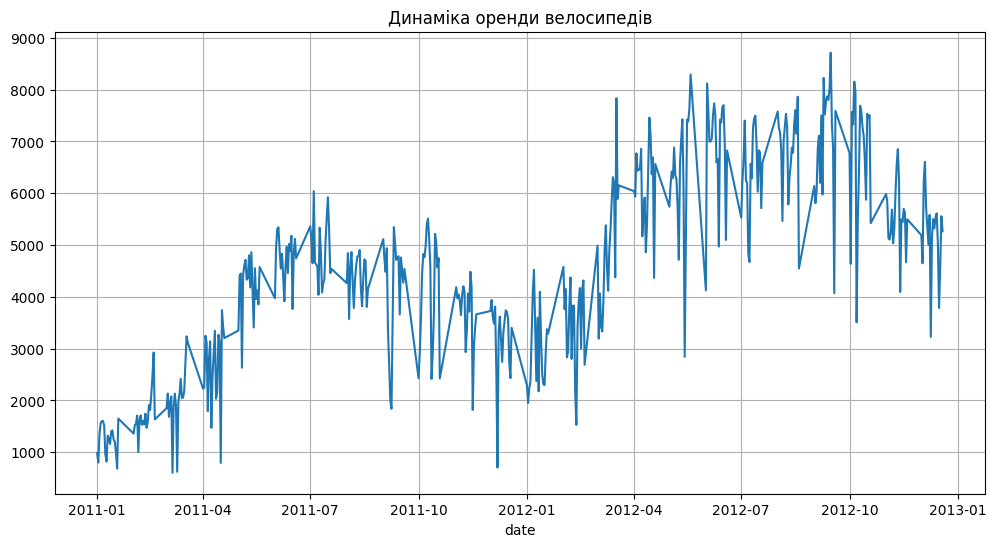

In [9]:
count_per_day.plot(
    figsize=(12,6),
    title='Динаміка оренди велосипедів',
    grid=True
);


In [10]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dt.day.max()

19

**Відповіді:**

1.Заломи спричинені тим, що дані за кожен місяць зібрані лише з 1 по 19
число. Проміжки від 20-го числа до початку наступного місяця з'єднані прямою лінією.
Щоб позбутися цього необхідно треба перетворити date на datetime та використати .resample('D') - відповідь нижче

2.Видно тенденцію до зростання популярності оренди велосипедів з 2011 по 2012рр.

3.Видно сезонні коливання. Пік оренди припадає на теплий сезон, і падає попит на зиму.

4.Аномально низькі значення в теплий сезон можуть бути пов'язані із погіршенням погоди(шторми, зливи)


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [11]:
avg_count_q = df.groupby('season')['count'].mean().round(0)
avg_count_q

,count
season,
1,116.0
2,215.0
3,234.0
4,199.0


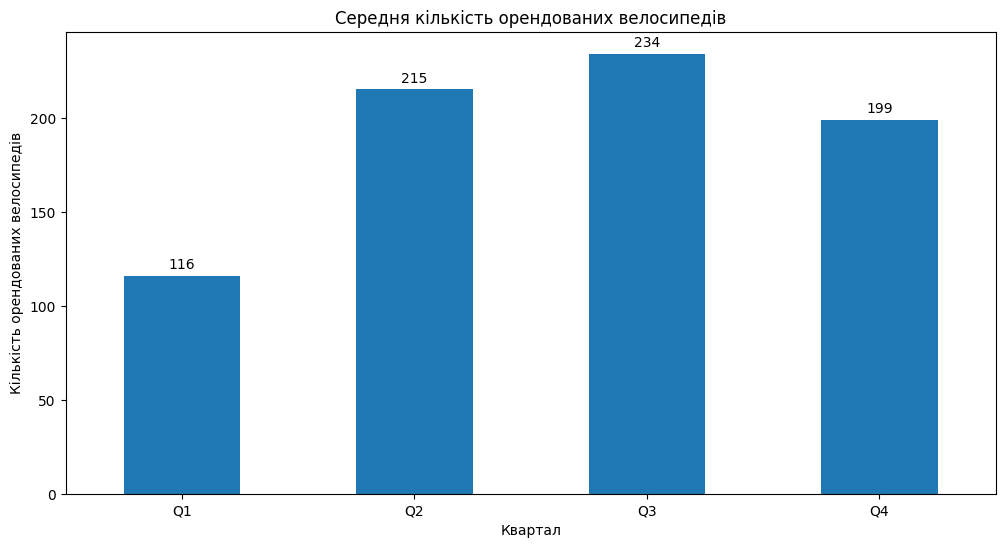

In [12]:
ax = avg_count_q.plot.bar(
    figsize=(12,6),
    title = 'Середня кількість орендованих велосипедів',
    xlabel = 'Квартал',
    ylabel = 'Кількість орендованих велосипедів'
)

labels = ['Q1', 'Q2', 'Q3', 'Q4']
ax.set_xticklabels(labels, rotation=0)
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=10)

plt.show()

**Відповідь**:

1.В 3 кварталі найбільша середня кількість оренди велосипедів

2.Краща погода в цей період

3.У 2 рази відрізняється оренда між найпопулярнішим та найменш популярним кварталами

In [13]:
q_dif = (avg_count_q.iloc[2] / avg_count_q.iloc[0]).round(0)
q_dif

np.float64(2.0)

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [14]:
avg_count_m = df.groupby('month')['count'].mean().round(0)
avg_count_m

,count
month,
1,90.0
2,110.0
3,148.0
4,184.0
5,219.0
6,242.0
7,235.0
8,234.0
9,234.0


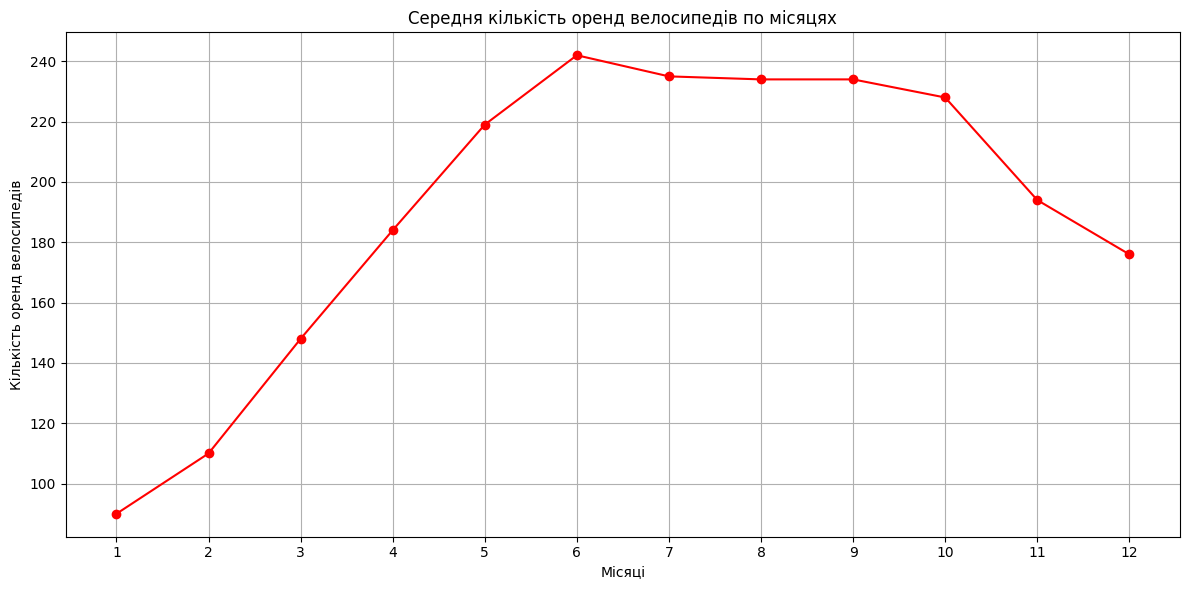

In [15]:
avg_count_m.plot(
    figsize = (12,6),
    title = 'Cередня кількість оренд велосипедів по місяцях',
    marker = 'o',
    grid = True,
    color = 'red',
    xlabel = 'Місяці',
    ylabel = 'Кількість оренд велосипедів',
    xticks = range(1, 13)
  )


plt.tight_layout()



**Відповіді:**

1.Пік оренди спостерігається у 6-му місяці, спад оренди починається з 10-го місяця.

2.Дані графіку свідчать, що місяці 3-го кварталу мають стабільно високу тенденцію попиту на оренду велосипедів. Тому ця закономірність збігається із графіком з попереднього завдання.

3.Покращення клімату, тепла погода може збільшити попит через бажання проводити більше часу на свіжому повітрі, а погіршення - його спад, відповідно у погану погоду люди більше обирають громадський транспорт.


## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

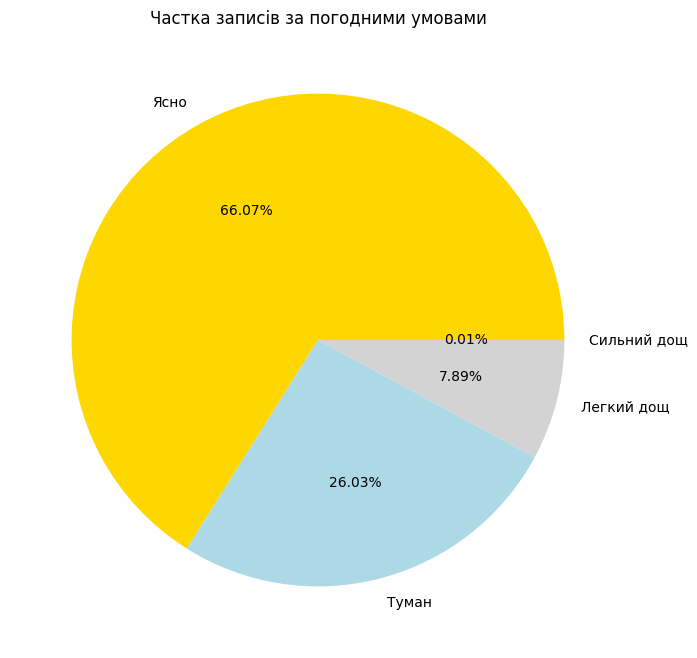

In [16]:

weather_q = df.groupby('weather')['count'].sum().round(3)
weather_q

,count
weather,
1,1476063
2,507160
3,102089
4,164


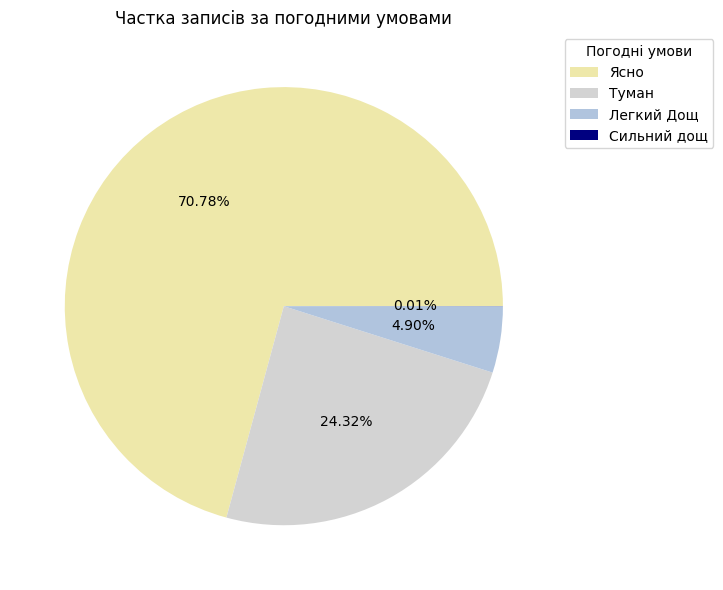

In [17]:
weather_q.plot.pie(
  figsize = (10,6),
  title = 'Частка записів за погодними умовами',
  autopct = '%1.2f%%',
  ylabel = '',
  colors = ['palegoldenrod', 'lightgray', 'lightsteelblue', 'navy'],
  labels = None
)

plt.legend(
    labels = ['Ясно', 'Туман', 'Легкий Дощ', 'Cильний дощ'],
    title = 'Погодні умови',
    bbox_to_anchor=(1.0, 1.0)
)
plt.tight_layout()
plt.show()

**Відповіді:**

1. У датасеті переважає ясна погода, на яку припадає понад 70% усіх орендованих велосипедів.
2. Так, дні/години із сильним дощем присутні, але їхня частка становить близько 0.01% (сумарно 164 оренди за весь період).
3. Погодні умови значно впливають на попит: ясна погода та туман сумарно забезпечують понад 95% усіх поїздок. Під час негоди попит різко падає, проте через низьку частоту дощів-показник оренди залишається високим.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

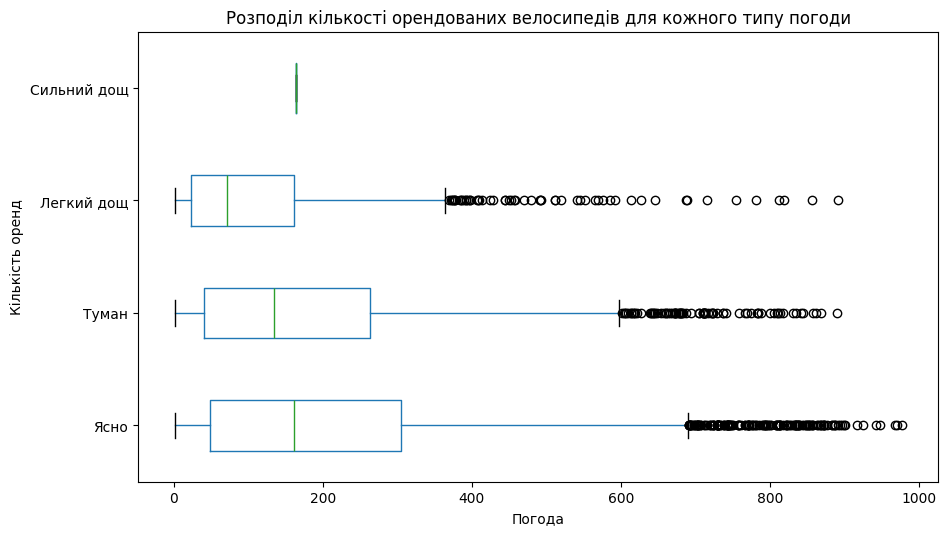

In [18]:
ax = df.boxplot(
    column = 'count',
    by = 'weather',
    figsize = (10,6),
    grid = False,
    vert=False

)

plt.title('Розподіл кількості орендованих велосипедів для кожного типу погоди')
plt.suptitle('')
plt.ylabel('Кількість оренд')
plt.xlabel('Погода')
ax.set_yticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.show()

**Відповіді:**

1.Найбільший розкид у кількості оренди стостерігається при ясній погоді.

2.Викиди (outliers) є. Вони спостерігаються при ясній, туманній погоді та коли йде легкий дощ.

3.При ясній погоді медіанне значення оренди найвище.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

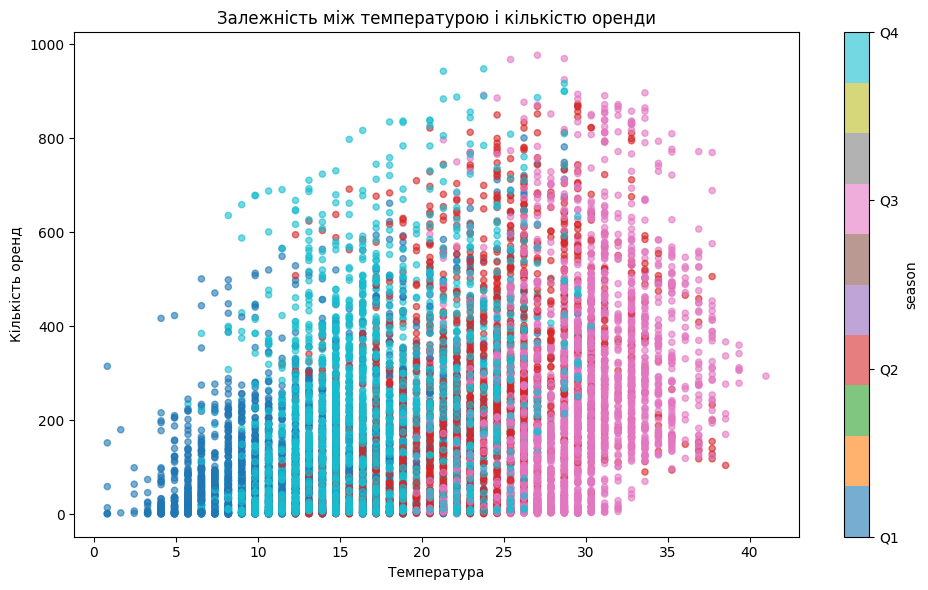

In [19]:
season_dict = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df['season_cat'] = df['season'].map(season_dict)

ax = df.plot.scatter(
    x = 'temp',
    y = 'count',
    c = 'season',
    title = 'Залежність між температурою і кількістю оренди',
    cmap='tab10',
    figsize = (10,6),
    alpha=0.6,
)

cbar = ax.collections[0].colorbar
cbar.set_ticks([1, 2, 3, 4])
cbar.set_ticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

plt.xlabel('Температура')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

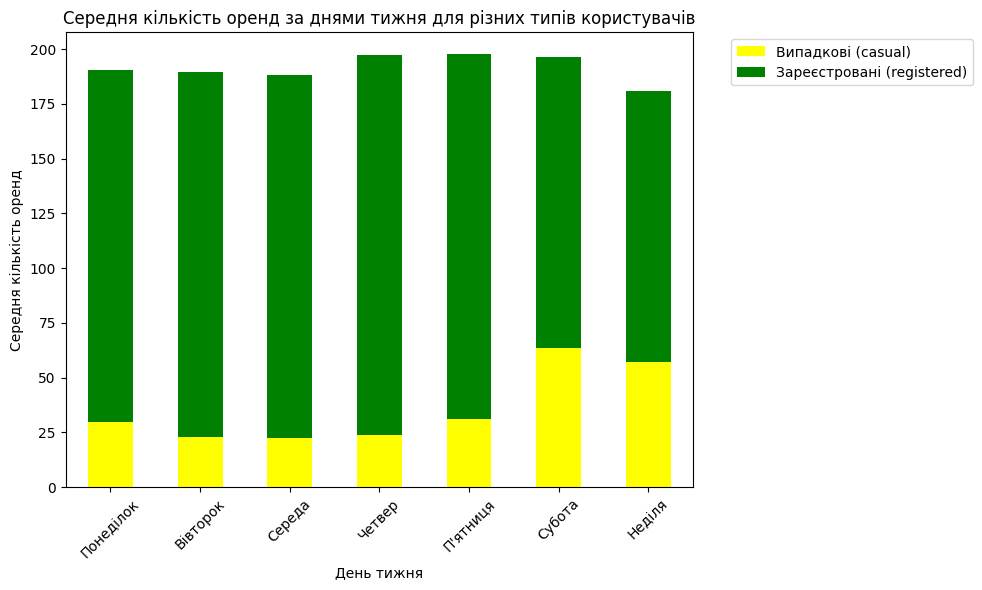

In [20]:
weekday_avg = df.groupby('weekday')[['casual', 'registered']].mean()
weekday_avg

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg.reindex(days_order)

weekday_avg.index = ['Понеділок', 'Вівторок', 'Середа', 'Четвер', "П'ятниця", 'Субота', 'Неділя']



ax = weekday_avg.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['yellow', 'green'],
    title='Середня кількість оренд за днями тижня для різних типів користувачів'
)


ax.set_xlabel('День тижня')
ax.set_ylabel('Середня кількість оренд')
ax.legend(
    ['Випадкові (casual)', 'Зареєстровані (registered)'],
    bbox_to_anchor=(1.05, 1)
)

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Відповідь:**
1.Найбільше оренд від зареєстрованих користувачів в Четвер.

2.Ми бачимо що протягом робочого тижня частка зареєстрованих і випадкових користувачів майже не змінюється. Зареєстровані користувачі використовують велосипеди як регулярний транспорт для щоденних поїздок на роботу чи навчання та назад.

На вихідних частка випадкових юзерів зростає. Вони орендують велосипеди переважно для відпочинку, прогулянок та дозвілля.